# Prequential Evaluation of Surrogate Models — Function 4

**Objective**: Compare three surrogate families on the warehouse product placement problem (Function 4) using **prequential (one-step-ahead) evaluation**.

## Function 4 Properties

| Property | Value |
|----------|-------|
| Problem | Warehouse product placement — optimally placing products across warehouses |
| Input dimensions | 4 |
| Output dimensions | 1 |
| Objective | Maximise |
| Input range | [0, 1] |
| Output characteristics | Wide negative range (-32.63 to 0.53); mean ≈ -14.72; std ≈ 8.66; many local optima |
| Initial samples | 30 |
| Total samples (Week 6) | 36 |
| Evaluation steps | 6 one-step-ahead predictions |

## Surrogate Models

1. **Single Fidelity GP (SF-GP)** — Standard GP via BoTorch `SingleTaskGP`
2. **Multi Fidelity GP (MF-GP)** — Autoregressive co-kriging GP via BoTorch `SingleTaskMultiFidelityGP`
3. **Gradient Boosted Trees (GBT)** — Ensemble tree model via scikit-learn `GradientBoostingRegressor` with quantile regression for uncertainty

## Methodology

For each surrogate, we:
1. Train on the initial 30 data points
2. Predict the next observation (one-step-ahead)
3. Record (prediction, uncertainty, actual)
4. Add the new point to the training set and retrain
5. Repeat until all 36 points have been processed (6 evaluation steps)

Each family is evaluated with **15 hyperparameter configurations** (45 total), and the best configuration from each family is compared in a three-way comparison.

### Why Multi Fidelity GP for F4

The Multi Fidelity GP uses an autoregressive co-kriging kernel structure:

$$f_{\text{high}}(x) = \rho \cdot f_{\text{low}}(x) + \delta(x)$$

The MF-GP's specialised kernel decomposition (task/fidelity component + spatial component) provides a different inductive bias than the standard `SingleTaskGP`. Even when all data is at a single fidelity level, the kernel structure acts as a form of regularisation that may improve predictions for problems with wide output ranges and many local optima like F4.

### Why Gradient Boosted Trees for F4

GBT builds an ensemble of weak decision tree learners sequentially, each correcting the previous ensemble's errors. For F4's 4D input space with wide output range, GBT can model complex non-linear relationships without Gaussian assumptions. Uncertainty is estimated via quantile regression (fitting separate models for the 2.5th and 97.5th percentiles).

## Evaluation Metrics

We evaluate each surrogate using three metrics:

1. **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values. Lower is better.

2. **NLP (Negative Log Predictive Density)**: Measures calibration quality — penalises both inaccurate means and overconfident/underconfident uncertainty. Lower is better.

   $$\text{NLP}_i = \frac{1}{2} \log(2\pi\sigma_i^2) + \frac{(y_i - \mu_i)^2}{2\sigma_i^2}$$

3. **95% Coverage**: Proportion of actual values falling within the 95% prediction interval ($\mu \pm 1.96\sigma$). Ideal value is 0.95.

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# BoTorch / GPyTorch for Gaussian Processes
import gpytorch
from botorch.models import SingleTaskGP
from botorch.models import SingleTaskMultiFidelityGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood
from botorch.models.transforms import Standardize, Normalize

# scikit-learn for Gradient Boosted Trees
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(42)
torch.manual_seed(42)
print('All imports successful.')

All imports successful.


## Step 1: Load Data

Load the Function 4 data. The `WEEK` variable controls which data snapshot to use (default: Week 6 with 36 total data points — 30 initial + 6 sequential observations).

Function 4 is a warehouse product placement problem with 4 input dimensions and 1 output. The output has a wide negative range (-32.63 to 0.53), meaning most configurations perform poorly and only a few yield near-zero or positive values.

In [2]:
# ── Configuration ─────────────────────────────────────────────
WEEK = 6
N_INIT = 30  # Number of initial training points (F4 starts with 30)

# ── Load data ─────────────────────────────────────────────────
X_all = np.load(f'../../data/f4/updated_inputs - Week {WEEK}.npy')
y_all = np.load(f'../../data/f4/updated_outputs - Week {WEEK}.npy')

# Flatten y if needed
if y_all.ndim > 1:
    y_all = y_all.flatten()

n_total = len(y_all)
n_steps = n_total - N_INIT

print(f'Function 4 — Warehouse Product Placement')
print(f'  Data loaded: Week {WEEK}')
print(f'  X shape: {X_all.shape}  (input dimensions: {X_all.shape[1]})')
print(f'  y shape: {y_all.shape}')
print(f'  Output range: [{y_all.min():.6f}, {y_all.max():.6f}]')
print(f'  Output mean:  {y_all.mean():.6f}')
print(f'  Output std:   {y_all.std():.6f}')
print(f'  Initial training points: {N_INIT}')
print(f'  Evaluation steps: {n_steps}')

Function 4 — Warehouse Product Placement
  Data loaded: Week 6
  X shape: (36, 4)  (input dimensions: 4)
  y shape: (36,)
  Output range: [-32.625660, 0.532175]
  Output mean:  -14.718473
  Output std:   8.658122
  Initial training points: 30
  Evaluation steps: 6


## Step 2: Define Evaluation Metrics

The `compute_metrics()` function computes MAE, NLP, and 95% Coverage from the one-step-ahead predictions.

In [3]:
def compute_metrics(predictions, actuals, pred_means, pred_stds):
    """
    Compute prequential evaluation metrics.
    
    Parameters
    ----------
    predictions : list of float — point predictions (mean) for each step
    actuals     : list of float — actual observed values for each step
    pred_means  : list of float — predicted means (same as predictions)
    pred_stds   : list of float — predicted standard deviations (uncertainty)
    
    Returns
    -------
    dict with MAE, NLP, Coverage_95, and per-step details
    """
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    pred_means = np.array(pred_means)
    pred_stds = np.array(pred_stds)
    
    # MAE
    mae = np.mean(np.abs(actuals - predictions))
    
    # Negative Log Predictive Density (NLP)
    # NLP_i = 0.5 * log(2*pi*sigma^2) + (y - mu)^2 / (2*sigma^2)
    stds_clipped = np.clip(pred_stds, 1e-10, None)
    nlp_values = 0.5 * np.log(2 * np.pi * stds_clipped**2) + \
                 (actuals - pred_means)**2 / (2 * stds_clipped**2)
    mean_nlp = np.mean(nlp_values)
    
    # 95% Prediction Interval Coverage
    lower = pred_means - 1.96 * stds_clipped
    upper = pred_means + 1.96 * stds_clipped
    in_interval = (actuals >= lower) & (actuals <= upper)
    coverage_95 = np.mean(in_interval)
    
    return {
        'MAE': mae,
        'NLP': mean_nlp,
        'Coverage_95': coverage_95,
        'nlp_values': nlp_values,
        'errors': actuals - predictions,
        'in_interval': in_interval
    }

print('compute_metrics() defined.')

compute_metrics() defined.


## Step 3: Single Fidelity GP Prequential Evaluation

The Single Fidelity GP (SF-GP) is the standard Gaussian Process via BoTorch `SingleTaskGP`. It treats all observations equally and uses Maximum Likelihood Estimation (MLE) to fit kernel hyperparameters.

Default configuration: Matérn 5/2 kernel with ARD (Automatic Relevance Determination) across all 4 input dimensions, learned noise level, and MLE fitting.

**Why ARD for F4**: With 4 warehouse placement parameters as inputs, ARD allows the GP to learn different lengthscales per dimension, capturing that some parameters may have stronger effects on the output than others.

In [4]:
def sfgp_prequential_evaluation(X_all, y_all, n_init):
    """
    Perform one-step-ahead prequential evaluation using a Single Fidelity GP.
    Default: Matern 5/2 kernel, ARD, learned noise.
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running Single Fidelity GP (Matern 5/2) prequential evaluation...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_all[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_all[n_train]
        
        # Build and fit GP model
        model = SingleTaskGP(X_train, y_train)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        
        # Predict
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('sfgp_prequential_evaluation() defined.')

sfgp_prequential_evaluation() defined.


### Run Single Fidelity GP with Default Hyperparameters

In [5]:
sfgp_default_results = sfgp_prequential_evaluation(X_all, y_all, N_INIT)

Running Single Fidelity GP (Matern 5/2) prequential evaluation...
  Training starts with 30 points, evaluating 6 steps

  Step 1: train=30 pts | predicted=-7.722006 | actual=-9.720482 | error=-1.998476 | std=1.814259
  Step 2: train=31 pts | predicted=-3.399902 | actual=-2.912760 | error=+0.487142 | std=0.347396
  Step 3: train=32 pts | predicted=-1.047576 | actual=+0.532175 | error=+1.579752 | std=0.514580
  Step 4: train=33 pts | predicted=+0.181751 | actual=+0.338389 | error=+0.156638 | std=0.412028
  Step 5: train=34 pts | predicted=+0.309471 | actual=+0.244750 | error=-0.064720 | std=0.271373
  Step 6: train=35 pts | predicted=-0.646512 | actual=-1.189486 | error=-0.542974 | std=0.383644

  Results:
    MAE:          0.804950
    Mean NLP:     1.4405
    95% Coverage: 83.3%


### SF-GP Default Results — Visualisation

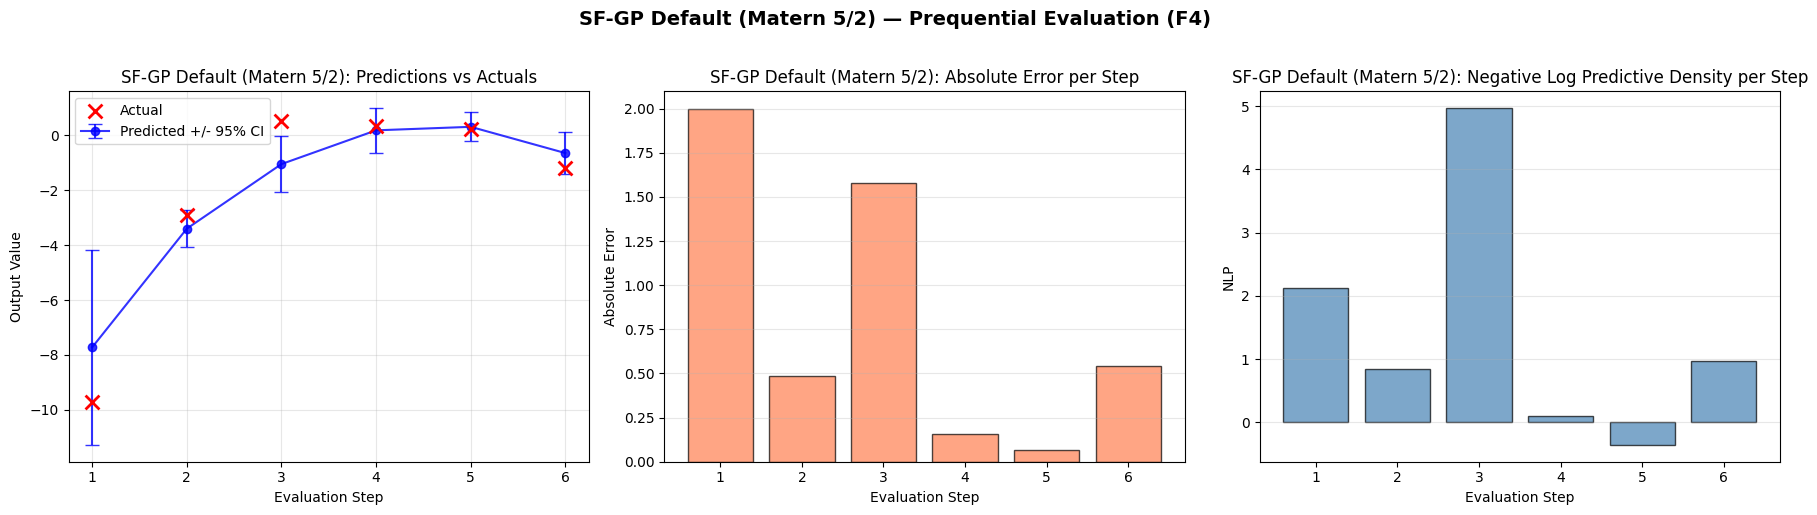

In [6]:
def plot_prequential_results(results, model_name):
    """Plot prequential evaluation results for a single model."""
    actuals = np.array(results['actuals'])
    preds = np.array(results['pred_means'])
    stds = np.array(results['pred_stds'])
    steps = np.arange(1, len(actuals) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Predictions vs Actuals with uncertainty
    ax = axes[0]
    ax.errorbar(steps, preds, yerr=1.96*stds, fmt='o-', color='blue',
                capsize=5, label='Predicted +/- 95% CI', alpha=0.8)
    ax.scatter(steps, actuals, color='red', s=100, zorder=5,
               marker='x', linewidths=2, label='Actual')
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Output Value')
    ax.set_title(f'{model_name}: Predictions vs Actuals')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Absolute errors
    ax = axes[1]
    errors = np.abs(actuals - preds)
    ax.bar(steps, errors, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Absolute Error')
    ax.set_title(f'{model_name}: Absolute Error per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: NLP per step
    ax = axes[2]
    nlp_vals = results['metrics']['nlp_values']
    ax.bar(steps, nlp_vals, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('NLP')
    ax.set_title(f'{model_name}: Negative Log Predictive Density per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'{model_name} — Prequential Evaluation (F4)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_prequential_results(sfgp_default_results, 'SF-GP Default (Matern 5/2)')

### SF-GP Hyperparameter Optimisation (15 Configurations)

We evaluate 15 Single Fidelity GP configurations varying:
- **Kernel type**: Matérn 5/2 vs Matérn 3/2 vs RBF
- **Output transform**: raw vs standardise (zero-mean, unit-variance) vs log-transform
- **Noise lower bound**: 1e-4, 1e-5, 1e-6

With F4's wide output range (-32.6 to 0.5), output standardisation or log-transform may significantly improve GP fitting quality. The 4 input dimensions benefit from ARD (used in all configurations).

In [7]:
def sfgp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run Single Fidelity GP prequential evaluation with a specific configuration.
    
    config dict keys:
        kernel_type    : 'matern52', 'matern32', or 'rbf'
        output_transform: 'raw', 'standardise', or 'log'
        noise_lb       : float - lower bound for noise
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals_transformed = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        
        # Apply output transform
        transform_type = config.get('output_transform', 'raw')
        if transform_type == 'log':
            # Sign-preserving log transform: sign(y) * log1p(|y|)
            # Consistent with np.expm1 inverse; handles F4's negative outputs
            y_work = np.sign(y_all) * np.log1p(np.abs(y_all))
        elif transform_type == 'standardise':
            y_work = y_all.copy()
            train_mean = y_all[:n_train].mean()
            train_std = y_all[:n_train].std() + 1e-10
            y_work = (y_work - train_mean) / train_std
        else:  # raw
            y_work = y_all.copy()
        
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_work[n_train]
        
        # Build kernel based on config
        d = X_train.shape[-1]
        kernel_type = config.get('kernel_type', 'matern52')
        if kernel_type == 'rbf':
            base_kernel = RBFKernel(ard_num_dims=d)
        elif kernel_type == 'matern32':
            base_kernel = MaternKernel(nu=1.5, ard_num_dims=d)
        else:  # matern52
            base_kernel = MaternKernel(nu=2.5, ard_num_dims=d)
        covar_module = ScaleKernel(base_kernel)
        
        # Build likelihood with noise lower bound
        noise_lb = config.get('noise_lb', 1e-5)
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        # Build GP model
        model = SingleTaskGP(
            X_train, y_train,
            covar_module=covar_module,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals_transformed.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    # Metrics in the space the model operates in
    metrics = compute_metrics(predictions, actuals_transformed, pred_means, pred_stds)
    
    # Also compute MAE in original space for interpretability
    if config.get('output_transform', 'raw') == 'log':
        # Inverse of sign-preserving log: sign(pred) * expm1(|pred|)
        preds_arr = np.array(predictions)
        orig_preds = np.sign(preds_arr) * np.expm1(np.abs(preds_arr))
        orig_actuals = y_all[n_init:]
        metrics['MAE_original'] = np.mean(np.abs(orig_actuals - orig_preds))
    elif config.get('output_transform', 'raw') == 'standardise':
        # Inverse standardisation would need per-step train stats — use NLP/Coverage as primary
        metrics['MAE_original'] = metrics['MAE']  # Already meaningful in standardised space
    else:
        metrics['MAE_original'] = metrics['MAE']
    
    return metrics


# ── 15 SF-GP Hyperparameter Configurations ──────────────────
# F4 has 4 input dims, wide output range (-32.6 to 0.5).
# We test 3 kernels × {raw, standardise, log} × 3 noise bounds,
# selecting 15 representative combinations.

sfgp_configs = [
    # Raw output, varying kernel and noise
    {'kernel_type': 'matern52', 'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'SF: Matern52, raw, noise>=1e-5'},
    {'kernel_type': 'matern52', 'output_transform': 'raw', 'noise_lb': 1e-4,
     'label': 'SF: Matern52, raw, noise>=1e-4'},
    {'kernel_type': 'matern52', 'output_transform': 'raw', 'noise_lb': 1e-6,
     'label': 'SF: Matern52, raw, noise>=1e-6'},
    {'kernel_type': 'matern32', 'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'SF: Matern32, raw, noise>=1e-5'},
    {'kernel_type': 'rbf', 'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'SF: RBF, raw, noise>=1e-5'},
    # Standardised output, varying kernel and noise
    {'kernel_type': 'matern52', 'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'SF: Matern52, standardise, noise>=1e-5'},
    {'kernel_type': 'matern52', 'output_transform': 'standardise', 'noise_lb': 1e-4,
     'label': 'SF: Matern52, standardise, noise>=1e-4'},
    {'kernel_type': 'matern32', 'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'SF: Matern32, standardise, noise>=1e-5'},
    {'kernel_type': 'matern32', 'output_transform': 'standardise', 'noise_lb': 1e-4,
     'label': 'SF: Matern32, standardise, noise>=1e-4'},
    {'kernel_type': 'rbf', 'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'SF: RBF, standardise, noise>=1e-5'},
    # Log-transformed output, varying kernel and noise
    {'kernel_type': 'matern52', 'output_transform': 'log', 'noise_lb': 1e-5,
     'label': 'SF: Matern52, log, noise>=1e-5'},
    {'kernel_type': 'matern52', 'output_transform': 'log', 'noise_lb': 1e-4,
     'label': 'SF: Matern52, log, noise>=1e-4'},
    {'kernel_type': 'matern32', 'output_transform': 'log', 'noise_lb': 1e-5,
     'label': 'SF: Matern32, log, noise>=1e-5'},
    {'kernel_type': 'rbf', 'output_transform': 'log', 'noise_lb': 1e-5,
     'label': 'SF: RBF, log, noise>=1e-5'},
    {'kernel_type': 'rbf', 'output_transform': 'log', 'noise_lb': 1e-6,
     'label': 'SF: RBF, log, noise>=1e-6'},
]

print(f'Running {len(sfgp_configs)} Single Fidelity GP configurations...\n')

sfgp_hp_results = []
for i, config in enumerate(sfgp_configs):
    print(f'  Config {i+1}/{len(sfgp_configs)}: {config["label"]}')
    try:
        metrics = sfgp_prequential_with_config(X_all, y_all, N_INIT, config)
        sfgp_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95'],
            'MAE_original': metrics['MAE_original']
        })
        print(f'    MAE={metrics["MAE"]:.6f}  NLP={metrics["NLP"]:.4f}  Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'    FAILED: {e}')
        sfgp_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan,
            'MAE_original': np.nan
        })

sfgp_hp_df = pd.DataFrame(sfgp_hp_results)
print(f'\nSF-GP Hyperparameter Results:')
sfgp_hp_df

Running 15 Single Fidelity GP configurations...

  Config 1/15: SF: Matern52, raw, noise>=1e-5
    MAE=0.705624  NLP=1.7943  Coverage=50.0%
  Config 2/15: SF: Matern52, raw, noise>=1e-4
    MAE=0.700515  NLP=1.4304  Coverage=66.7%
  Config 3/15: SF: Matern52, raw, noise>=1e-6
    MAE=0.706828  NLP=1.9064  Coverage=50.0%
  Config 4/15: SF: Matern32, raw, noise>=1e-5
    MAE=0.502629  NLP=0.8542  Coverage=100.0%
  Config 5/15: SF: RBF, raw, noise>=1e-5
    MAE=0.937745  NLP=4.7415  Coverage=50.0%
  Config 6/15: SF: Matern52, standardise, noise>=1e-5
    MAE=0.097075  NLP=-0.2362  Coverage=50.0%
  Config 7/15: SF: Matern52, standardise, noise>=1e-4
    MAE=0.096442  NLP=-0.6001  Coverage=66.7%
  Config 8/15: SF: Matern32, standardise, noise>=1e-5
    MAE=0.069063  NLP=-1.1763  Coverage=100.0%
  Config 9/15: SF: Matern32, standardise, noise>=1e-4
    MAE=0.070820  NLP=-1.1298  Coverage=83.3%
  Config 10/15: SF: RBF, standardise, noise>=1e-5
    MAE=0.128504  NLP=2.7110  Coverage=50.0%
  Co

,label,MAE,NLP,Coverage_95,MAE_original
0,"SF: Matern52, raw, noise>=1e-5",0.705624,1.794300,0.500000,0.705624
1,"SF: Matern52, raw, noise>=1e-4",0.700515,1.430368,0.666667,0.700515
2,"SF: Matern52, raw, noise>=1e-6",0.706828,1.906399,0.500000,0.706828
3,"SF: Matern32, raw, noise>=1e-5",0.502629,0.854163,1.000000,0.502629
4,"SF: RBF, raw, noise>=1e-5",0.937745,4.741457,0.500000,0.937745
5,"SF: Matern52, standardise, noise>=1e-5",0.097075,-0.236168,0.500000,0.097075
6,"SF: Matern52, standardise, noise>=1e-4",0.096442,-0.600100,0.666667,0.096442
7,"SF: Matern32, standardise, noise>=1e-5",0.069063,-1.176305,1.000000,0.069063
8,"SF: Matern32, standardise, noise>=1e-4",0.070820,-1.129818,0.833333,0.070820
9,"SF: RBF, standardise, noise>=1e-5",0.128504,2.710988,0.500000,0.128504


### Best Single Fidelity GP Configuration

In [8]:
# Best SF-GP by NLP (primary metric)
best_sfgp_idx = sfgp_hp_df['NLP'].idxmin()
best_sfgp = sfgp_hp_df.loc[best_sfgp_idx]
print(f'Best SF-GP by NLP:')
print(f'  Config:    {best_sfgp["label"]}')
print(f'  MAE:       {best_sfgp["MAE"]:.6f}')
print(f'  NLP:       {best_sfgp["NLP"]:.4f}')
print(f'  Coverage:  {best_sfgp["Coverage_95"]:.1%}')

# Best SF-GP by MAE (secondary)
best_sfgp_mae_idx = sfgp_hp_df['MAE'].idxmin()
if best_sfgp_mae_idx != best_sfgp_idx:
    best_sfgp_mae = sfgp_hp_df.loc[best_sfgp_mae_idx]
    print(f'\nBest SF-GP by MAE (different from NLP-best):')
    print(f'  Config:    {best_sfgp_mae["label"]}')
    print(f'  MAE:       {best_sfgp_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_sfgp_mae["NLP"]:.4f}')

Best SF-GP by NLP:
  Config:    SF: Matern32, standardise, noise>=1e-5
  MAE:       0.069063
  NLP:       -1.1763
  Coverage:  100.0%


## Step 4: Multi Fidelity GP Prequential Evaluation

The Multi Fidelity GP (MF-GP) uses BoTorch's `SingleTaskMultiFidelityGP`, which applies an autoregressive co-kriging kernel structure. This model augments the input with a **fidelity column** and uses a specialised kernel that decomposes the covariance into a task/fidelity component and a spatial component.

For our prequential evaluation, we append a constant fidelity column (all 1.0) to the inputs. While all data is at the same fidelity level, the MF-GP's kernel structure provides a **different inductive bias** than the standard `SingleTaskGP`:
- The `LinearTruncatedFidelityKernel` or downsampling kernel adds structure to the covariance
- This can act as a form of regularisation, potentially beneficial for F4's wide output range

**Hyperparameters**:
- `nu`: Matérn kernel smoothness (2.5, 1.5) — controls the smoothness of the spatial component
- `linear_truncated`: Whether to use the `LinearTruncatedFidelityKernel` (True) or standard downsampling (False)
- Output transform: raw vs standardise
- Noise lower bound: Controls the noise floor

In [9]:
def mfgp_prequential_evaluation(X_all, y_all, n_init, nu=2.5, linear_truncated=True):
    """
    Perform one-step-ahead prequential evaluation using a Multi Fidelity GP.
    Uses BoTorch SingleTaskMultiFidelityGP with a synthetic fidelity column.
    
    Parameters
    ----------
    X_all : array (n, d) — all inputs
    y_all : array (n,) — all outputs
    n_init : int — number of initial training points
    nu : float — Matern kernel smoothness (2.5 or 1.5)
    linear_truncated : bool — use LinearTruncatedFidelityKernel
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running Multi Fidelity GP (nu={nu}, linear_truncated={linear_truncated}) prequential evaluation...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_all[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_all[n_train]
        
        # Append fidelity column (all 1.0 = high fidelity)
        fidelity_train = torch.ones(n_train, 1, dtype=torch.float64)
        X_train_mf = torch.cat([X_train, fidelity_train], dim=-1)
        
        fidelity_test = torch.ones(1, 1, dtype=torch.float64)
        X_test_mf = torch.cat([X_test, fidelity_test], dim=-1)
        
        # Build Multi Fidelity GP
        # data_fidelities specifies which column indices are fidelity features
        model = SingleTaskMultiFidelityGP(
            X_train_mf, y_train,
            data_fidelities=[X_train_mf.shape[-1] - 1],  # last col = fidelity
            linear_truncated=linear_truncated,
            nu=nu,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        # Predict at test point (at fidelity=1.0)
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test_mf)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('mfgp_prequential_evaluation() defined.')

mfgp_prequential_evaluation() defined.


### Run Multi Fidelity GP with Default Hyperparameters

In [10]:
mfgp_default_results = mfgp_prequential_evaluation(X_all, y_all, N_INIT, nu=2.5, linear_truncated=True)

Running Multi Fidelity GP (nu=2.5, linear_truncated=True) prequential evaluation...
  Training starts with 30 points, evaluating 6 steps

  Step 1: train=30 pts | predicted=-8.914872 | actual=-9.720482 | error=-0.805610 | std=2.849431
  Step 2: train=31 pts | predicted=-3.351111 | actual=-2.912760 | error=+0.438351 | std=0.467678
  Step 3: train=32 pts | predicted=-1.353080 | actual=+0.532175 | error=+1.885255 | std=1.081241
  Step 4: train=33 pts | predicted=+0.428860 | actual=+0.338389 | error=-0.090472 | std=0.515289
  Step 5: train=34 pts | predicted=+0.318479 | actual=+0.244750 | error=-0.073729 | std=0.321017
  Step 6: train=35 pts | predicted=-0.955977 | actual=-1.189486 | error=-0.233508 | std=0.702386

  Results:
    MAE:          0.587821
    Mean NLP:     0.9704
    95% Coverage: 100.0%


### MF-GP Default Results — Visualisation

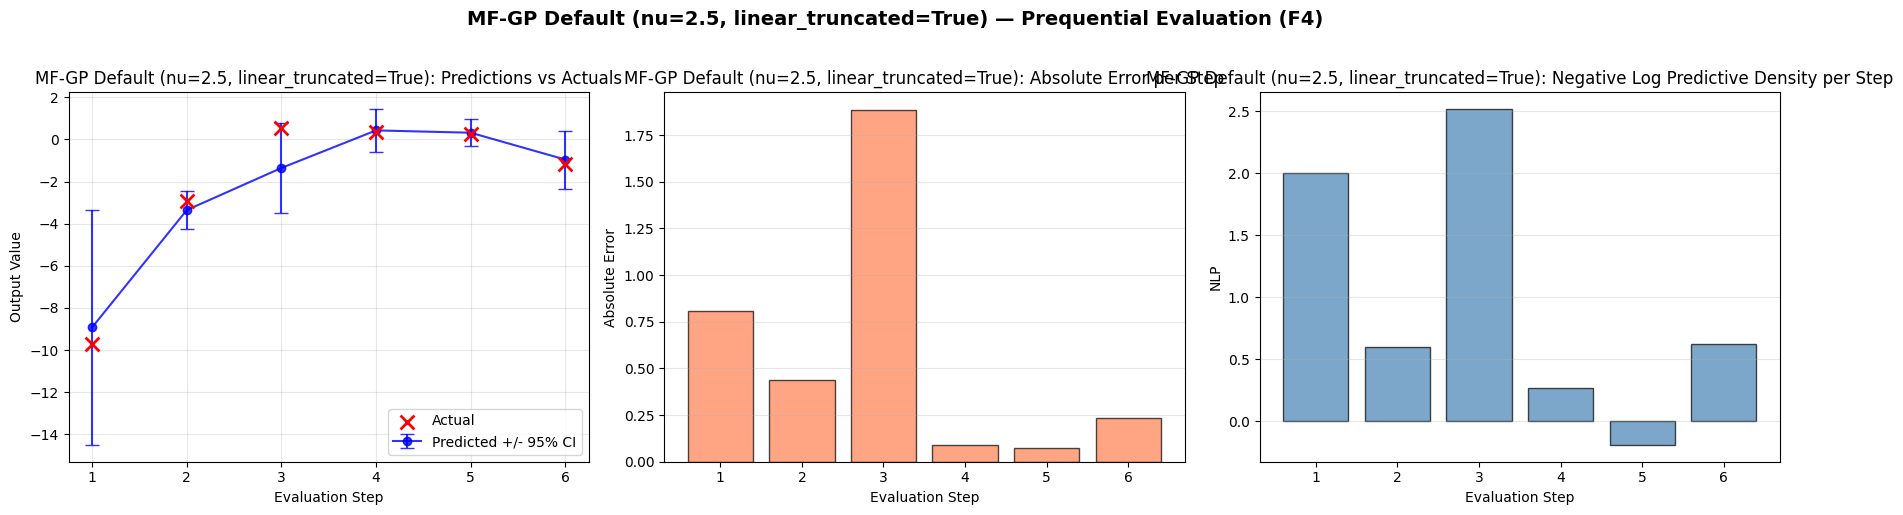

In [11]:
plot_prequential_results(mfgp_default_results, 'MF-GP Default (nu=2.5, linear_truncated=True)')

### MF-GP Hyperparameter Optimisation (15 Configurations)

We evaluate 15 Multi Fidelity GP configurations varying:
- **Matérn smoothness (nu)**: 2.5 (twice differentiable), 1.5 (once differentiable)
- **Fidelity kernel**: `linear_truncated=True` (LinearTruncatedFidelityKernel) vs `linear_truncated=False` (standard exponential decay)
- **Output transform**: raw vs standardise
- **Noise lower bound**: 1e-4, 1e-5, 1e-6

The MF-GP uses its own specialised kernel structure, so we vary `nu` and `linear_truncated` rather than manually specifying the full covariance module.

In [12]:
def mfgp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run Multi Fidelity GP prequential evaluation with a specific configuration.
    
    config dict keys:
        nu               : float (2.5 or 1.5) — Matern smoothness
        linear_truncated : bool — use LinearTruncatedFidelityKernel
        output_transform : 'raw' or 'standardise'
        noise_lb         : float — lower bound for noise
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals_transformed = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        
        # Apply output transform
        transform_type = config.get('output_transform', 'raw')
        if transform_type == 'standardise':
            train_mean = y_all[:n_train].mean()
            train_std = y_all[:n_train].std() + 1e-10
            y_work = (y_all - train_mean) / train_std
        else:  # raw
            y_work = y_all.copy()
        
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_work[n_train]
        
        # Append fidelity column
        fidelity_train = torch.ones(n_train, 1, dtype=torch.float64)
        X_train_mf = torch.cat([X_train, fidelity_train], dim=-1)
        
        fidelity_test = torch.ones(1, 1, dtype=torch.float64)
        X_test_mf = torch.cat([X_test, fidelity_test], dim=-1)
        
        # Build MF-GP
        nu = config.get('nu', 2.5)
        linear_truncated = config.get('linear_truncated', True)
        noise_lb = config.get('noise_lb', 1e-5)
        
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        model = SingleTaskMultiFidelityGP(
            X_train_mf, y_train,
            data_fidelities=[X_train_mf.shape[-1] - 1],
            linear_truncated=linear_truncated,
            nu=nu,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test_mf)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals_transformed.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    metrics = compute_metrics(predictions, actuals_transformed, pred_means, pred_stds)
    metrics['MAE_original'] = metrics['MAE']  # For standardised, NLP/Coverage are primary
    
    return metrics


# ── 15 MF-GP Hyperparameter Configurations ─────────────────
# F4: 4D inputs, wide output range. We vary:
# - nu (2.5, 1.5): smoothness of the spatial kernel
# - linear_truncated (True, False): fidelity kernel structure
# - output_transform (raw, standardise): important for wide output range
# - noise_lb (1e-4, 1e-5, 1e-6): noise floor

mfgp_configs = [
    # Raw output, nu=2.5, varying fidelity kernel and noise
    {'nu': 2.5, 'linear_truncated': True,  'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'MF: nu=2.5, LinTrunc, raw, noise>=1e-5'},
    {'nu': 2.5, 'linear_truncated': True,  'output_transform': 'raw', 'noise_lb': 1e-4,
     'label': 'MF: nu=2.5, LinTrunc, raw, noise>=1e-4'},
    {'nu': 2.5, 'linear_truncated': True,  'output_transform': 'raw', 'noise_lb': 1e-6,
     'label': 'MF: nu=2.5, LinTrunc, raw, noise>=1e-6'},
    {'nu': 2.5, 'linear_truncated': False, 'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'MF: nu=2.5, ExpDecay, raw, noise>=1e-5'},
    {'nu': 2.5, 'linear_truncated': False, 'output_transform': 'raw', 'noise_lb': 1e-4,
     'label': 'MF: nu=2.5, ExpDecay, raw, noise>=1e-4'},
    # Raw output, nu=1.5
    {'nu': 1.5, 'linear_truncated': True,  'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'MF: nu=1.5, LinTrunc, raw, noise>=1e-5'},
    {'nu': 1.5, 'linear_truncated': True,  'output_transform': 'raw', 'noise_lb': 1e-4,
     'label': 'MF: nu=1.5, LinTrunc, raw, noise>=1e-4'},
    {'nu': 1.5, 'linear_truncated': False, 'output_transform': 'raw', 'noise_lb': 1e-5,
     'label': 'MF: nu=1.5, ExpDecay, raw, noise>=1e-5'},
    # Standardised output, nu=2.5
    {'nu': 2.5, 'linear_truncated': True,  'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'MF: nu=2.5, LinTrunc, standardise, noise>=1e-5'},
    {'nu': 2.5, 'linear_truncated': True,  'output_transform': 'standardise', 'noise_lb': 1e-4,
     'label': 'MF: nu=2.5, LinTrunc, standardise, noise>=1e-4'},
    {'nu': 2.5, 'linear_truncated': False, 'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'MF: nu=2.5, ExpDecay, standardise, noise>=1e-5'},
    {'nu': 2.5, 'linear_truncated': False, 'output_transform': 'standardise', 'noise_lb': 1e-4,
     'label': 'MF: nu=2.5, ExpDecay, standardise, noise>=1e-4'},
    # Standardised output, nu=1.5
    {'nu': 1.5, 'linear_truncated': True,  'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'MF: nu=1.5, LinTrunc, standardise, noise>=1e-5'},
    {'nu': 1.5, 'linear_truncated': True,  'output_transform': 'standardise', 'noise_lb': 1e-4,
     'label': 'MF: nu=1.5, LinTrunc, standardise, noise>=1e-4'},
    {'nu': 1.5, 'linear_truncated': False, 'output_transform': 'standardise', 'noise_lb': 1e-5,
     'label': 'MF: nu=1.5, ExpDecay, standardise, noise>=1e-5'},
]

print(f'Running {len(mfgp_configs)} Multi Fidelity GP configurations...\n')

mfgp_hp_results = []
for i, config in enumerate(mfgp_configs):
    print(f'  Config {i+1}/{len(mfgp_configs)}: {config["label"]}')
    try:
        metrics = mfgp_prequential_with_config(X_all, y_all, N_INIT, config)
        mfgp_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95'],
            'MAE_original': metrics['MAE_original']
        })
        print(f'    MAE={metrics["MAE"]:.6f}  NLP={metrics["NLP"]:.4f}  Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'    FAILED: {e}')
        mfgp_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan,
            'MAE_original': np.nan
        })

mfgp_hp_df = pd.DataFrame(mfgp_hp_results)
print(f'\nMF-GP Hyperparameter Results:')
mfgp_hp_df

Running 15 Multi Fidelity GP configurations...

  Config 1/15: MF: nu=2.5, LinTrunc, raw, noise>=1e-5
    MAE=0.488465  NLP=0.7607  Coverage=100.0%
  Config 2/15: MF: nu=2.5, LinTrunc, raw, noise>=1e-4
    MAE=0.472176  NLP=0.6837  Coverage=100.0%
  Config 3/15: MF: nu=2.5, LinTrunc, raw, noise>=1e-6
    MAE=0.489605  NLP=0.7815  Coverage=100.0%
  Config 4/15: MF: nu=2.5, ExpDecay, raw, noise>=1e-5
    MAE=0.938123  NLP=4.7463  Coverage=50.0%
  Config 5/15: MF: nu=2.5, ExpDecay, raw, noise>=1e-4
    MAE=0.924283  NLP=2.3467  Coverage=50.0%
  Config 6/15: MF: nu=1.5, LinTrunc, raw, noise>=1e-5
    MAE=0.450929  NLP=0.9565  Coverage=100.0%
  Config 7/15: MF: nu=1.5, LinTrunc, raw, noise>=1e-4
    MAE=0.453824  NLP=0.9746  Coverage=100.0%
  Config 8/15: MF: nu=1.5, ExpDecay, raw, noise>=1e-5
    MAE=0.938123  NLP=4.7463  Coverage=50.0%
  Config 9/15: MF: nu=2.5, LinTrunc, standardise, noise>=1e-5
    MAE=0.066437  NLP=-1.2697  Coverage=100.0%
  Config 10/15: MF: nu=2.5, LinTrunc, standard

,label,MAE,NLP,Coverage_95,MAE_original
0,"MF: nu=2.5, LinTrunc, raw, noise>=1e-5",0.488465,0.760743,1.0,0.488465
1,"MF: nu=2.5, LinTrunc, raw, noise>=1e-4",0.472176,0.683661,1.0,0.472176
2,"MF: nu=2.5, LinTrunc, raw, noise>=1e-6",0.489605,0.781547,1.0,0.489605
3,"MF: nu=2.5, ExpDecay, raw, noise>=1e-5",0.938123,4.746299,0.5,0.938123
4,"MF: nu=2.5, ExpDecay, raw, noise>=1e-4",0.924283,2.346723,0.5,0.924283
5,"MF: nu=1.5, LinTrunc, raw, noise>=1e-5",0.450929,0.956509,1.0,0.450929
6,"MF: nu=1.5, LinTrunc, raw, noise>=1e-4",0.453824,0.974582,1.0,0.453824
7,"MF: nu=1.5, ExpDecay, raw, noise>=1e-5",0.938123,4.746299,0.5,0.938123
8,"MF: nu=2.5, LinTrunc, standardise, noise>=1e-5",0.066437,-1.269725,1.0,0.066437
9,"MF: nu=2.5, LinTrunc, standardise, noise>=1e-4",0.064830,-1.346807,1.0,0.064830


### Best Multi Fidelity GP Configuration

In [13]:
# Best MF-GP by NLP (primary metric)
best_mfgp_idx = mfgp_hp_df['NLP'].idxmin()
best_mfgp = mfgp_hp_df.loc[best_mfgp_idx]
print(f'Best MF-GP by NLP:')
print(f'  Config:    {best_mfgp["label"]}')
print(f'  MAE:       {best_mfgp["MAE"]:.6f}')
print(f'  NLP:       {best_mfgp["NLP"]:.4f}')
print(f'  Coverage:  {best_mfgp["Coverage_95"]:.1%}')

# Best MF-GP by MAE (secondary)
best_mfgp_mae_idx = mfgp_hp_df['MAE'].idxmin()
if best_mfgp_mae_idx != best_mfgp_idx:
    best_mfgp_mae = mfgp_hp_df.loc[best_mfgp_mae_idx]
    print(f'\nBest MF-GP by MAE (different from NLP-best):')
    print(f'  Config:    {best_mfgp_mae["label"]}')
    print(f'  MAE:       {best_mfgp_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_mfgp_mae["NLP"]:.4f}')

Best MF-GP by NLP:
  Config:    MF: nu=2.5, LinTrunc, standardise, noise>=1e-4
  MAE:       0.064830
  NLP:       -1.3468
  Coverage:  100.0%

Best MF-GP by MAE (different from NLP-best):
  Config:    MF: nu=1.5, LinTrunc, standardise, noise>=1e-5
  MAE:       0.061478
  NLP:       -1.0740


## Step 4b: Gradient Boosted Trees (GBT) Prequential Evaluation

Gradient Boosted Trees (GBT) build an ensemble of weak decision tree learners, each trained sequentially to correct the errors of the previous ensemble. We use scikit-learn's `GradientBoostingRegressor`.

### Uncertainty Estimation via Quantile Regression

Unlike GPs, GBT does not natively provide uncertainty estimates. We use **quantile regression** to estimate prediction intervals:
- Fit a **mean model** with `loss='squared_error'` (standard regression)
- Fit a **lower bound model** with `loss='quantile'`, `alpha=0.025` (2.5th percentile)
- Fit an **upper bound model** with `loss='quantile'`, `alpha=0.975` (97.5th percentile)

The standard deviation is estimated as: $\sigma \approx \frac{q_{97.5} - q_{2.5}}{2 \times 1.96}$

### Key Hyperparameters

| Parameter | Description | Default |
|-----------|-------------|---------|
| `n_estimators` | Number of boosting stages (trees) | 100 |
| `learning_rate` | Shrinkage factor per tree contribution | 0.1 |
| `max_depth` | Maximum depth of each tree | 3 |
| `min_samples_leaf` | Minimum samples per leaf node | 2 |
| `subsample` | Fraction of samples used per tree | 0.8 |

### Why GBT for F4

F4 has a wide output range (-32.6 to 0.5) and potentially complex non-linear relationships across 4 input dimensions. GBT is robust to outliers, can model non-linear interactions, and does not assume Gaussian noise. With 30 initial training points, GBT has sufficient data to build meaningful ensembles.

In [19]:
def gbt_prequential_evaluation(X_all, y_all, n_init, n_estimators=100,
                                learning_rate=0.1, max_depth=3,
                                min_samples_leaf=2, subsample=0.8):
    """
    Perform one-step-ahead prequential evaluation using Gradient Boosted Trees.
    
    Uncertainty is estimated via quantile regression:
    - Mean model: loss='squared_error'
    - Lower bound: loss='quantile', alpha=0.025
    - Upper bound: loss='quantile', alpha=0.975
    
    Parameters
    ----------
    X_all : ndarray, shape (n, 4) — all input points
    y_all : ndarray, shape (n,)   — all output values
    n_init : int — number of initial training points
    n_estimators : int — number of boosting stages
    learning_rate : float — shrinkage factor
    max_depth : int — maximum depth of each tree
    min_samples_leaf : int — minimum samples per leaf
    subsample : float — fraction of samples per tree
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running GBT prequential evaluation...')
    print(f'  n_estimators={n_estimators}, lr={learning_rate}, '
          f'max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, '
          f'subsample={subsample}')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # ── Mean model (squared error) ──
        gbt_mean = GradientBoostingRegressor(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            subsample=subsample, loss='squared_error', random_state=42
        )
        gbt_mean.fit(X_train, y_train)
        mean = gbt_mean.predict(X_test)[0]
        
        # ── Lower quantile model (2.5th percentile) ──
        gbt_lower = GradientBoostingRegressor(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            subsample=subsample, loss='quantile', alpha=0.025, random_state=42
        )
        gbt_lower.fit(X_train, y_train)
        lower = gbt_lower.predict(X_test)[0]
        
        # ── Upper quantile model (97.5th percentile) ──
        gbt_upper = GradientBoostingRegressor(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            subsample=subsample, loss='quantile', alpha=0.975, random_state=42
        )
        gbt_upper.fit(X_train, y_train)
        upper = gbt_upper.predict(X_test)[0]
        
        # ── Estimate std from quantile spread ──
        # 95% interval width = upper - lower ≈ 2 * 1.96 * sigma
        std = max((upper - lower) / (2 * 1.96), 1e-10)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('gbt_prequential_evaluation() defined.')

gbt_prequential_evaluation() defined.


### Run GBT with Default Hyperparameters

In [20]:
gbt_default_results = gbt_prequential_evaluation(X_all, y_all, N_INIT)

Running GBT prequential evaluation...
  n_estimators=100, lr=0.1, max_depth=3, min_samples_leaf=2, subsample=0.8
  Training starts with 30 points, evaluating 6 steps

  Step 1: train=30 pts | predicted=-10.728197 | actual=-9.720482 | error=+1.007715 | std=3.782563
  Step 2: train=31 pts | predicted=-6.165824 | actual=-2.912760 | error=+3.253064 | std=4.511703
  Step 3: train=32 pts | predicted=-5.386962 | actual=+0.532175 | error=+5.919137 | std=4.936504
  Step 4: train=33 pts | predicted=-1.340134 | actual=+0.338389 | error=+1.678523 | std=6.359851
  Step 5: train=34 pts | predicted=-0.002900 | actual=+0.244750 | error=+0.247650 | std=6.273174
  Step 6: train=35 pts | predicted=-0.803941 | actual=-1.189486 | error=-0.385544 | std=6.397072

  Results:
    MAE:          2.081939
    Mean NLP:     2.7569
    95% Coverage: 100.0%


### GBT Default Results — Visualisation

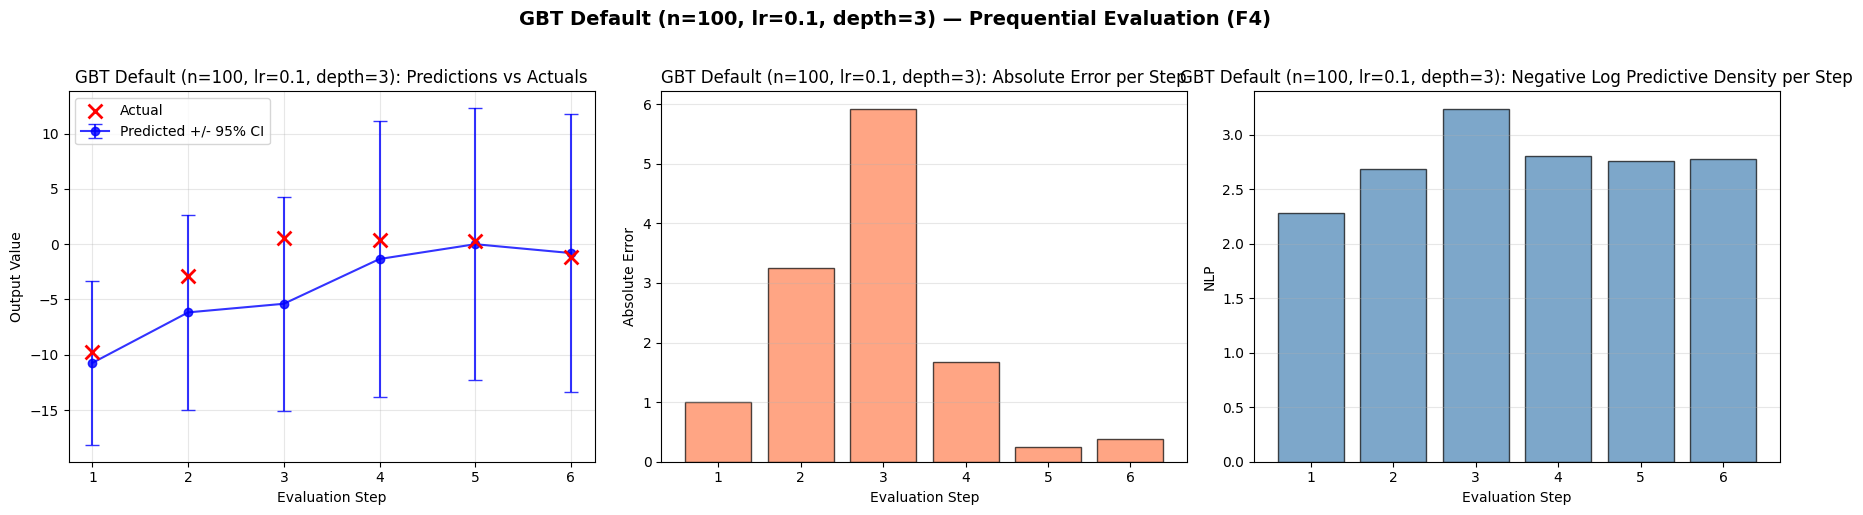

In [21]:
plot_prequential_results(gbt_default_results, 'GBT Default (n=100, lr=0.1, depth=3)')

### GBT Hyperparameter Optimisation (15 Configurations)

We evaluate 15 GBT configurations varying:
- **n_estimators**: 50, 100, 200, 500 — controls ensemble size. More trees reduce bias but increase computation.
- **learning_rate**: 0.01, 0.05, 0.1, 0.2 — shrinkage rate. Lower values need more trees but generalise better.
- **max_depth**: 3, 4, 5, 6 — tree depth. Deeper trees capture more complex interactions but risk overfitting with 30 training points.
- **min_samples_leaf**: 1, 2, 5 — regularisation via minimum leaf size. Higher values prevent overfitting on small datasets.
- **subsample**: 0.8, 1.0 — stochastic gradient boosting fraction. Values < 1.0 introduce randomness for better generalisation.

Each configuration fits 3 models (mean + 2 quantiles) × 6 steps = 18 model fits.

In [22]:
def gbt_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run GBT prequential evaluation with a specific configuration.
    
    Parameters
    ----------
    config : dict with keys:
        n_estimators, learning_rate, max_depth, min_samples_leaf, subsample, label
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals_list = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # ── Mean model ──
        gbt_mean = GradientBoostingRegressor(
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            max_depth=config['max_depth'],
            min_samples_leaf=config['min_samples_leaf'],
            subsample=config['subsample'],
            loss='squared_error', random_state=42
        )
        gbt_mean.fit(X_train, y_train)
        mean = gbt_mean.predict(X_test)[0]
        
        # ── Lower quantile (2.5th percentile) ──
        gbt_lower = GradientBoostingRegressor(
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            max_depth=config['max_depth'],
            min_samples_leaf=config['min_samples_leaf'],
            subsample=config['subsample'],
            loss='quantile', alpha=0.025, random_state=42
        )
        gbt_lower.fit(X_train, y_train)
        lower = gbt_lower.predict(X_test)[0]
        
        # ── Upper quantile (97.5th percentile) ──
        gbt_upper = GradientBoostingRegressor(
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            max_depth=config['max_depth'],
            min_samples_leaf=config['min_samples_leaf'],
            subsample=config['subsample'],
            loss='quantile', alpha=0.975, random_state=42
        )
        gbt_upper.fit(X_train, y_train)
        upper = gbt_upper.predict(X_test)[0]
        
        # Estimate std from quantile spread
        std = max((upper - lower) / (2 * 1.96), 1e-10)
        
        predictions.append(mean)
        actuals_list.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    return compute_metrics(predictions, actuals_list, pred_means, pred_stds)


# ── 15 GBT configurations ────────────────────────────────────
# Selected to cover: ensemble size, learning rate, tree depth, 
# regularisation, and stochastic boosting

gbt_configs = [
    # Baseline configurations
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.10 d=3 msl=2 ss=0.8'},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 1.0,
     'label': 'GBT n=100 lr=0.10 d=3 msl=2 ss=1.0'},
    
    # Vary learning rate (lower = more conservative)
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=200 lr=0.05 d=3 msl=2 ss=0.8'},
    {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=500 lr=0.01 d=3 msl=2 ss=0.8'},
    {'n_estimators': 100, 'learning_rate': 0.2,  'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.20 d=3 msl=2 ss=0.8'},
    
    # Vary tree depth (deeper = more complex interactions)
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 4, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.10 d=4 msl=2 ss=0.8'},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.10 d=5 msl=2 ss=0.8'},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 6, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.10 d=6 msl=2 ss=0.8'},
    
    # Vary min_samples_leaf (higher = more regularisation)
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_samples_leaf': 1, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.10 d=3 msl=1 ss=0.8'},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_samples_leaf': 5, 'subsample': 0.8,
     'label': 'GBT n=100 lr=0.10 d=3 msl=5 ss=0.8'},
    
    # Larger ensembles with moderate learning rate
    {'n_estimators': 200, 'learning_rate': 0.1,  'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=200 lr=0.10 d=3 msl=2 ss=0.8'},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=500 lr=0.05 d=3 msl=2 ss=0.8'},
    
    # Small ensemble (fast, may underfit)
    {'n_estimators': 50,  'learning_rate': 0.2,  'max_depth': 4, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=50  lr=0.20 d=4 msl=2 ss=0.8'},
    
    # Combination: deep trees + low learning rate + large ensemble
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'subsample': 0.8,
     'label': 'GBT n=200 lr=0.05 d=5 msl=2 ss=0.8'},
    
    # Combination: high regularisation + moderate ensemble
    {'n_estimators': 200, 'learning_rate': 0.1,  'max_depth': 4, 'min_samples_leaf': 5, 'subsample': 0.8,
     'label': 'GBT n=200 lr=0.10 d=4 msl=5 ss=0.8'},
]

print(f'Defined {len(gbt_configs)} GBT configurations.')
print(f'Running GBT HP optimisation...\n')

gbt_hp_results = []
for i, config in enumerate(gbt_configs):
    print(f'  [{i+1}/{len(gbt_configs)}] {config["label"]}', end=' ... ')
    try:
        metrics = gbt_prequential_with_config(X_all, y_all, N_INIT, config)
        gbt_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95']
        })
        print(f'MAE={metrics["MAE"]:.4f}, NLP={metrics["NLP"]:.4f}, '
              f'Cov={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'FAILED: {e}')
        gbt_hp_results.append({
            'label': config['label'],
            'MAE': float('nan'),
            'NLP': float('nan'),
            'Coverage_95': float('nan')
        })

gbt_hp_df = pd.DataFrame(gbt_hp_results)
print(f'\nGBT Hyperparameter Results:')
gbt_hp_df

Defined 15 GBT configurations.
Running GBT HP optimisation...

  [1/15] GBT n=100 lr=0.10 d=3 msl=2 ss=0.8 ... MAE=2.0819, NLP=2.7569, Cov=100.0%
  [2/15] GBT n=100 lr=0.10 d=3 msl=2 ss=1.0 ... MAE=2.4675, NLP=2.8609, Cov=100.0%
  [3/15] GBT n=200 lr=0.05 d=3 msl=2 ss=0.8 ... MAE=2.0907, NLP=2.7159, Cov=100.0%
  [4/15] GBT n=500 lr=0.01 d=3 msl=2 ss=0.8 ... MAE=2.5999, NLP=2.8955, Cov=100.0%
  [5/15] GBT n=100 lr=0.20 d=3 msl=2 ss=0.8 ... MAE=1.7802, NLP=2.6661, Cov=100.0%
  [6/15] GBT n=100 lr=0.10 d=4 msl=2 ss=0.8 ... MAE=1.8118, NLP=2.7287, Cov=100.0%
  [7/15] GBT n=100 lr=0.10 d=5 msl=2 ss=0.8 ... MAE=1.9636, NLP=2.7351, Cov=100.0%
  [8/15] GBT n=100 lr=0.10 d=6 msl=2 ss=0.8 ... MAE=1.9069, NLP=2.7265, Cov=100.0%
  [9/15] GBT n=100 lr=0.10 d=3 msl=1 ss=0.8 ... MAE=1.9310, NLP=2.8104, Cov=100.0%
  [10/15] GBT n=100 lr=0.10 d=3 msl=5 ss=0.8 ... MAE=1.7993, NLP=2.7309, Cov=83.3%
  [11/15] GBT n=200 lr=0.10 d=3 msl=2 ss=0.8 ... MAE=1.9509, NLP=2.6825, Cov=100.0%
  [12/15] GBT n=500 lr=

,label,MAE,NLP,Coverage_95
0,GBT n=100 lr=0.10 d=3 msl=2 ss=0.8,2.081939,2.756868,1.000000
1,GBT n=100 lr=0.10 d=3 msl=2 ss=1.0,2.467477,2.860854,1.000000
2,GBT n=200 lr=0.05 d=3 msl=2 ss=0.8,2.090726,2.715914,1.000000
3,GBT n=500 lr=0.01 d=3 msl=2 ss=0.8,2.599886,2.895504,1.000000
4,GBT n=100 lr=0.20 d=3 msl=2 ss=0.8,1.780194,2.666143,1.000000
5,GBT n=100 lr=0.10 d=4 msl=2 ss=0.8,1.811843,2.728695,1.000000
6,GBT n=100 lr=0.10 d=5 msl=2 ss=0.8,1.963629,2.735118,1.000000
7,GBT n=100 lr=0.10 d=6 msl=2 ss=0.8,1.906903,2.726534,1.000000
8,GBT n=100 lr=0.10 d=3 msl=1 ss=0.8,1.931031,2.810401,1.000000
9,GBT n=100 lr=0.10 d=3 msl=5 ss=0.8,1.799261,2.730950,0.833333


### Best GBT Configuration

In [23]:
# Best GBT by NLP (primary metric)
best_gbt_idx = gbt_hp_df['NLP'].idxmin()
best_gbt = gbt_hp_df.loc[best_gbt_idx]
print(f'Best GBT by NLP:')
print(f'  Config:    {best_gbt["label"]}')
print(f'  MAE:       {best_gbt["MAE"]:.6f}')
print(f'  NLP:       {best_gbt["NLP"]:.4f}')
print(f'  Coverage:  {best_gbt["Coverage_95"]:.1%}')

# Best GBT by MAE (secondary)
best_gbt_mae_idx = gbt_hp_df['MAE'].idxmin()
if best_gbt_mae_idx != best_gbt_idx:
    best_gbt_mae = gbt_hp_df.loc[best_gbt_mae_idx]
    print(f'\nBest GBT by MAE (different from NLP-best):')
    print(f'  Config:    {best_gbt_mae["label"]}')
    print(f'  MAE:       {best_gbt_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_gbt_mae["NLP"]:.4f}')

Best GBT by NLP:
  Config:    GBT n=200 lr=0.10 d=4 msl=5 ss=0.8
  MAE:       1.554927
  NLP:       2.5486
  Coverage:  83.3%


## Step 5: Model Comparison — SF-GP vs MF-GP vs GBT

We compare the **best configuration** from each surrogate family (selected by lowest NLP) in a three-way comparison.

In [24]:
# ── Build 3-way comparison table ─────────────────────────────
comparison_data = [
    {
        'Model': 'SF-GP',
        'Configuration': best_sfgp['label'],
        'MAE': best_sfgp['MAE'],
        'NLP': best_sfgp['NLP'],
        'Coverage_95': best_sfgp['Coverage_95']
    },
    {
        'Model': 'MF-GP',
        'Configuration': best_mfgp['label'],
        'MAE': best_mfgp['MAE'],
        'NLP': best_mfgp['NLP'],
        'Coverage_95': best_mfgp['Coverage_95']
    },
    {
        'Model': 'GBT',
        'Configuration': best_gbt['label'],
        'MAE': best_gbt['MAE'],
        'NLP': best_gbt['NLP'],
        'Coverage_95': best_gbt['Coverage_95']
    }
]

comparison_df = pd.DataFrame(comparison_data)

# ── Determine metric-by-metric winners ────────────────────────
print('=== 3-Way Comparison: Best SF-GP vs Best MF-GP vs Best GBT ===')
print()
print(comparison_df.to_string(index=False))

# MAE: lower is better
mae_winner_idx = comparison_df['MAE'].idxmin()
mae_winner = comparison_df.loc[mae_winner_idx, 'Model']

# NLP: lower is better
nlp_winner_idx = comparison_df['NLP'].idxmin()
nlp_winner = comparison_df.loc[nlp_winner_idx, 'Model']

# Coverage: closer to 0.95 is better
cov_diffs = comparison_df['Coverage_95'].apply(lambda x: abs(x - 0.95))
cov_winner_idx = cov_diffs.idxmin()
cov_winner = comparison_df.loc[cov_winner_idx, 'Model']

print(f'\n--- Metric Winners ---')
print(f'  Best MAE:      {mae_winner} ({comparison_df.loc[mae_winner_idx, "MAE"]:.6f})')
print(f'  Best NLP:      {nlp_winner} ({comparison_df.loc[nlp_winner_idx, "NLP"]:.4f})')
print(f'  Best Coverage: {cov_winner} ({comparison_df.loc[cov_winner_idx, "Coverage_95"]:.1%})')

# Overall winner by NLP (primary metric)
print(f'\n  >>> Overall winner for F4 (by NLP): {nlp_winner} <<<')

=== 3-Way Comparison: Best SF-GP vs Best MF-GP vs Best GBT ===

Model                                  Configuration      MAE       NLP  Coverage_95
SF-GP         SF: Matern32, standardise, noise>=1e-5 0.069063 -1.176305     1.000000
MF-GP MF: nu=2.5, LinTrunc, standardise, noise>=1e-4 0.064830 -1.346807     1.000000
  GBT             GBT n=200 lr=0.10 d=4 msl=5 ss=0.8 1.554927  2.548596     0.833333

--- Metric Winners ---
  Best MAE:      MF-GP (0.064830)
  Best NLP:      MF-GP (-1.3468)
  Best Coverage: SF-GP (100.0%)

  >>> Overall winner for F4 (by NLP): MF-GP <<<


### Visual Comparison

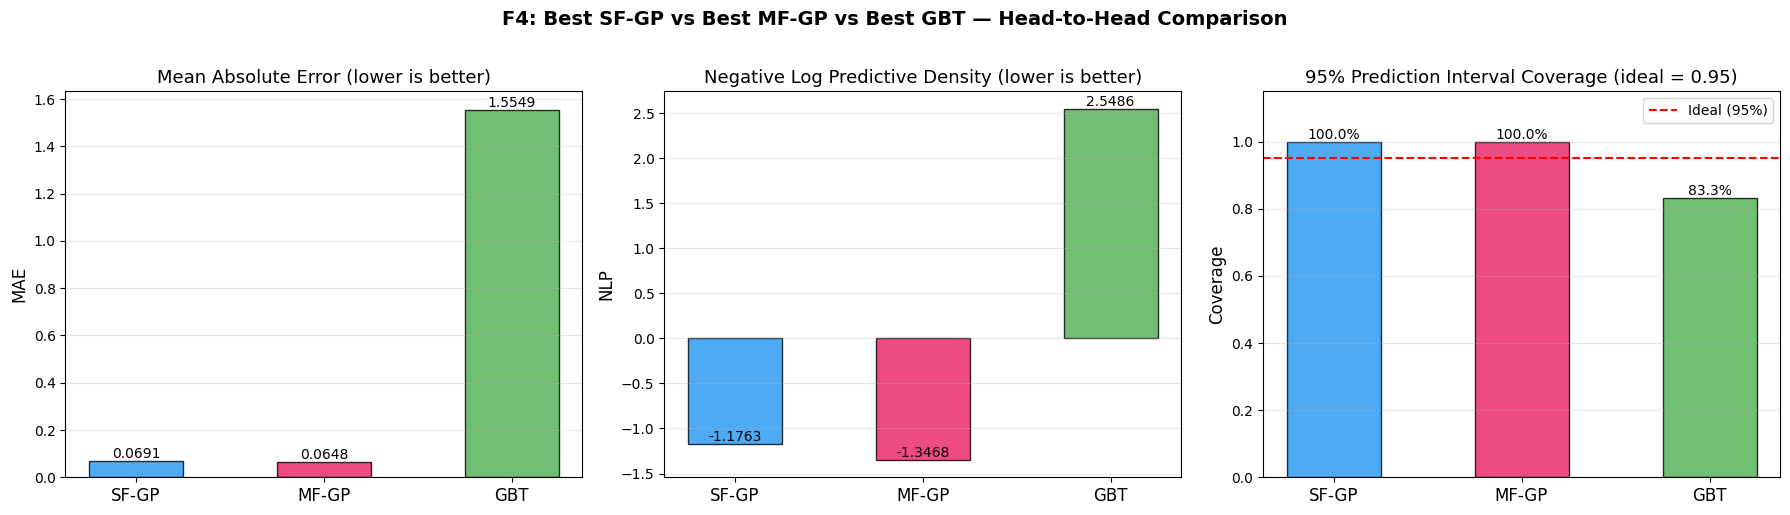

In [25]:
# ── 3-panel bar chart: MAE, NLP, Coverage ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['SF-GP', 'MF-GP', 'GBT']
colors = ['#2196F3', '#E91E63', '#4CAF50']  # Blue, Pink, Green
x = np.arange(len(models))

# MAE
ax = axes[0]
mae_vals = comparison_df['MAE'].values
bars = ax.bar(x, mae_vals, color=colors, edgecolor='black', alpha=0.8, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Mean Absolute Error (lower is better)', fontsize=13)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# NLP
ax = axes[1]
nlp_vals = comparison_df['NLP'].values
bars = ax.bar(x, nlp_vals, color=colors, edgecolor='black', alpha=0.8, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('NLP', fontsize=12)
ax.set_title('Negative Log Predictive Density (lower is better)', fontsize=13)
for bar, val in zip(bars, nlp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Coverage
ax = axes[2]
cov_vals = comparison_df['Coverage_95'].values
bars = ax.bar(x, cov_vals, color=colors, edgecolor='black', alpha=0.8, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('95% Prediction Interval Coverage (ideal = 0.95)', fontsize=13)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='Ideal (95%)')
for bar, val in zip(bars, cov_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('F4: Best SF-GP vs Best MF-GP vs Best GBT — Head-to-Head Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Hyperparameter Sensitivity — All Configurations

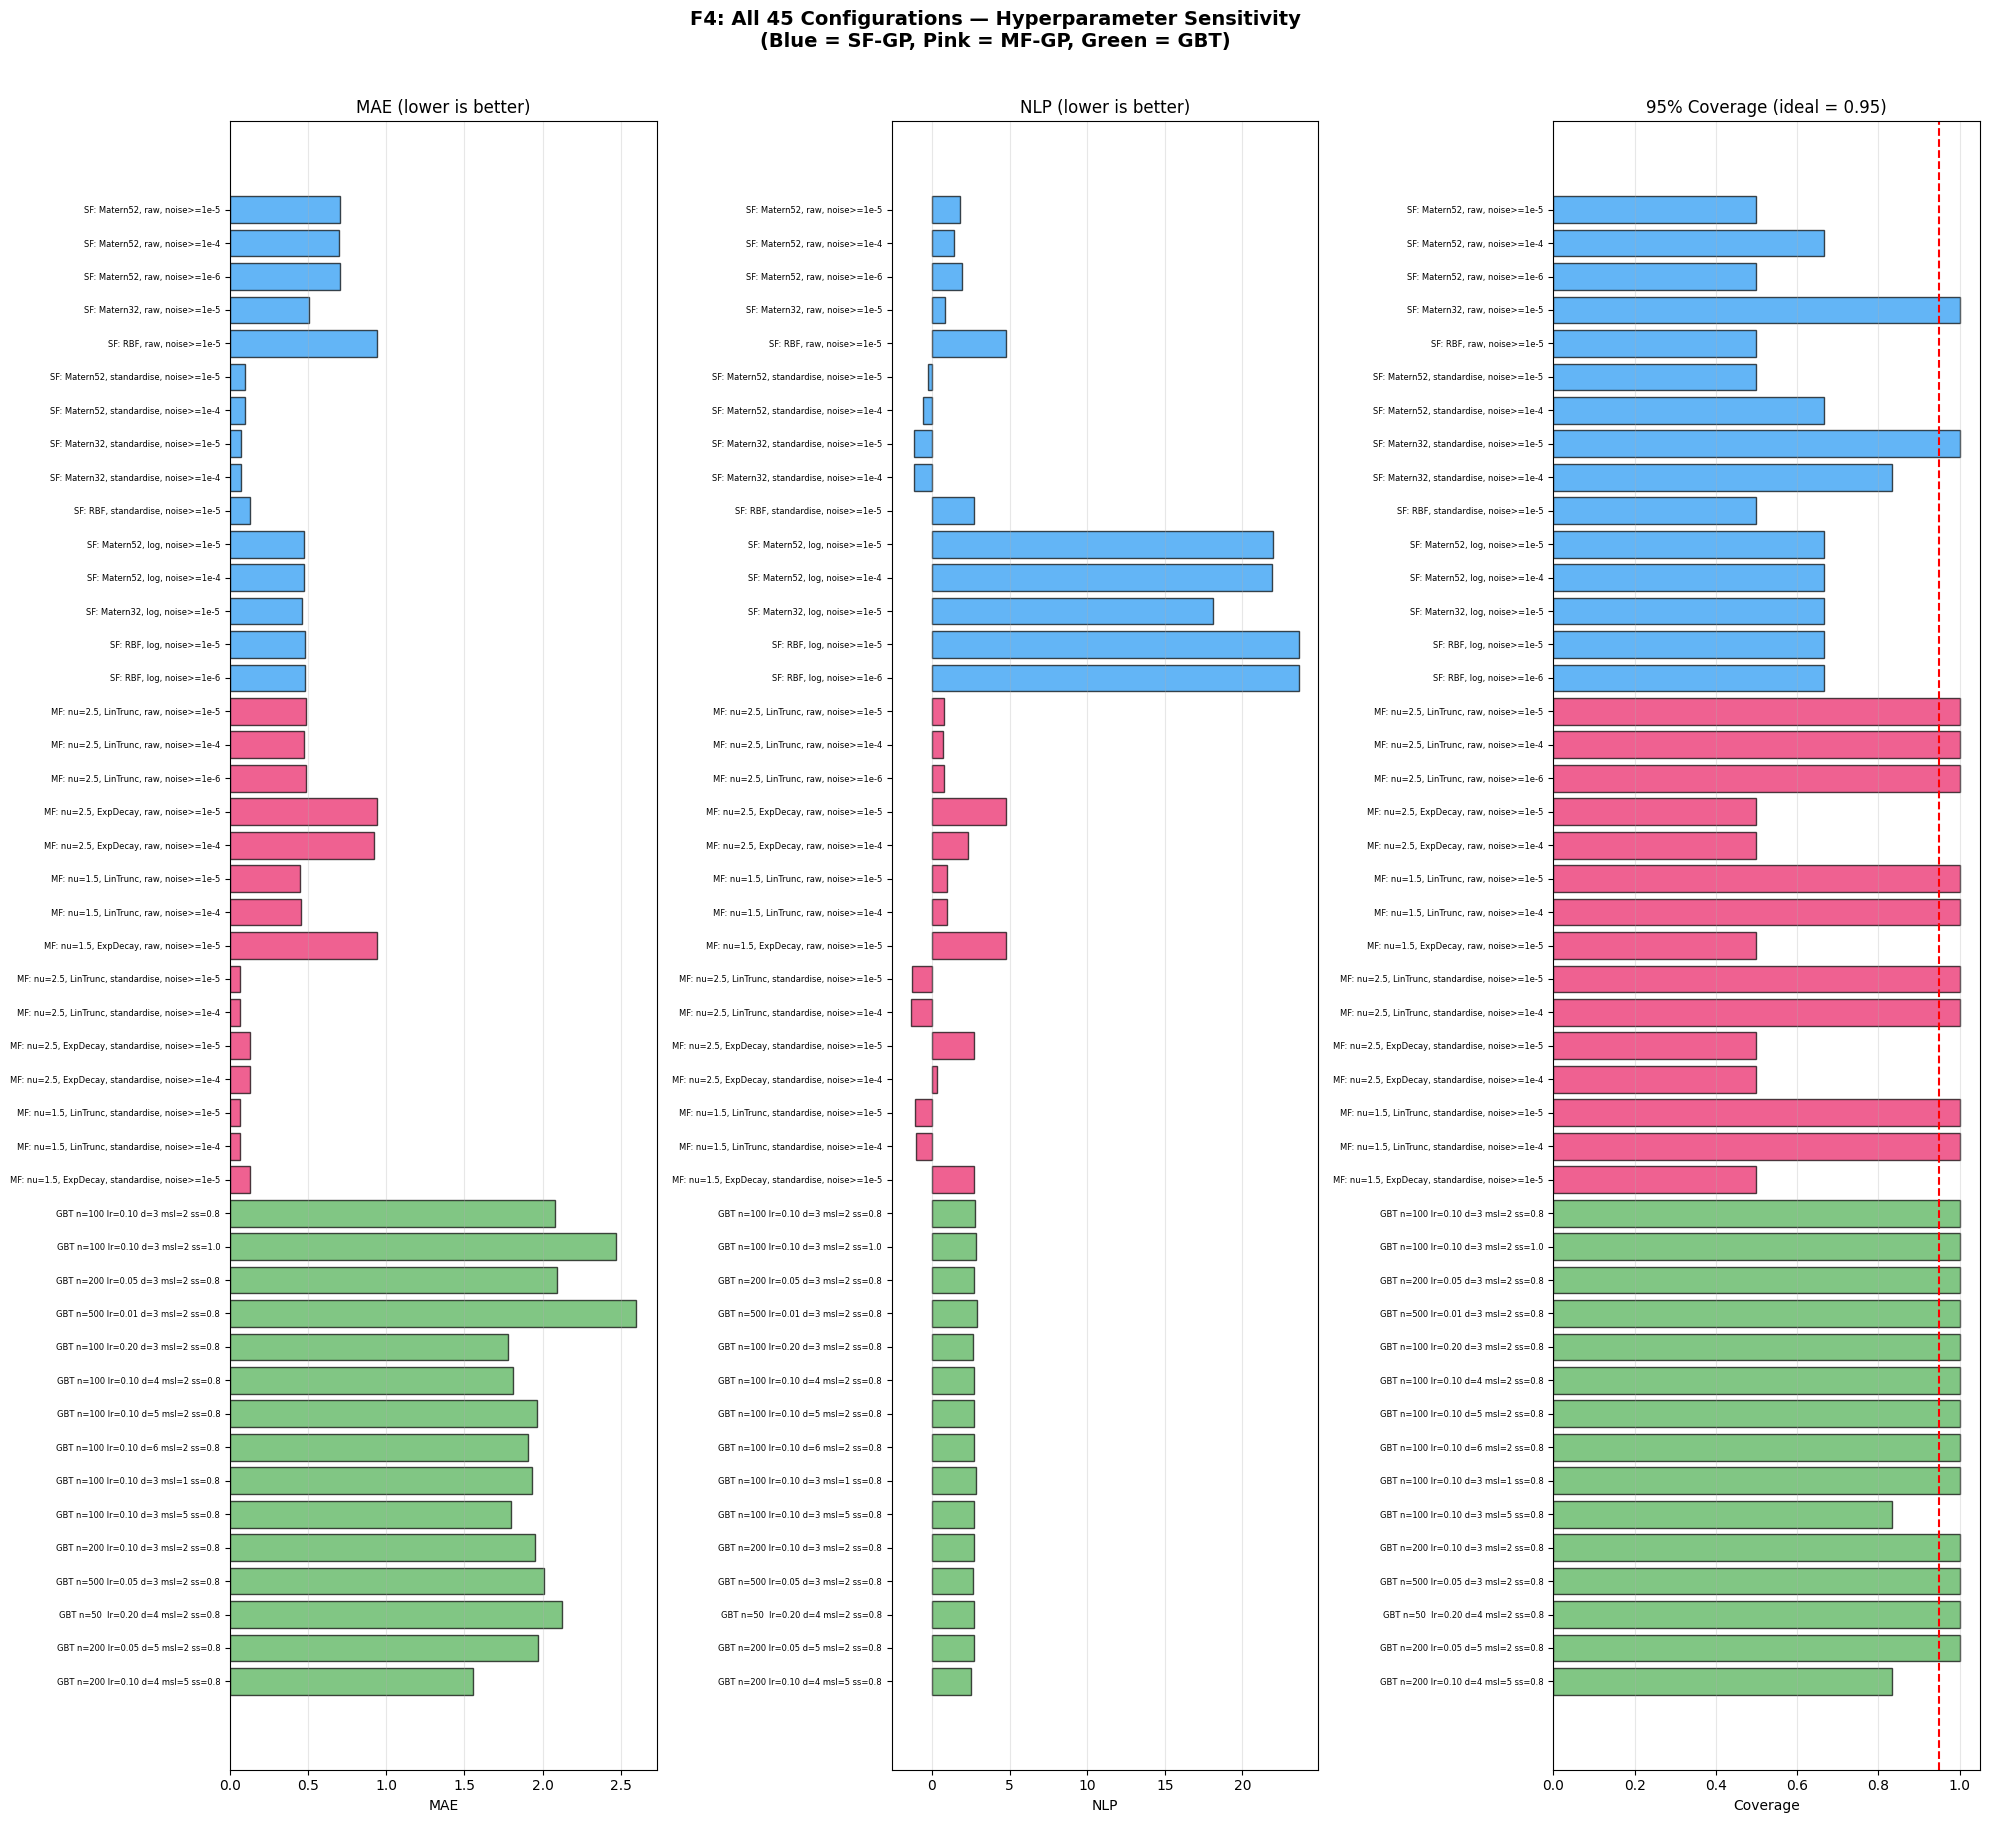

In [26]:
# ── Horizontal bar charts for all 45 configs ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 18))

# Combine all results with model prefix
all_labels = []
all_mae = []
all_nlp = []
all_cov = []
all_colors = []

for _, row in sfgp_hp_df.iterrows():
    all_labels.append(row['label'])
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#2196F3')  # Blue for SF-GP

for _, row in mfgp_hp_df.iterrows():
    all_labels.append(row['label'])
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#E91E63')  # Pink for MF-GP

for _, row in gbt_hp_df.iterrows():
    all_labels.append(row['label'])
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#4CAF50')  # Green for GBT

y_pos = np.arange(len(all_labels))

# MAE
ax = axes[0]
ax.barh(y_pos, all_mae, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=6)
ax.set_xlabel('MAE')
ax.set_title('MAE (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# NLP
ax = axes[1]
ax.barh(y_pos, all_nlp, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=6)
ax.set_xlabel('NLP')
ax.set_title('NLP (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Coverage
ax = axes[2]
ax.barh(y_pos, all_cov, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=6)
ax.set_xlabel('Coverage')
ax.set_title('95% Coverage (ideal = 0.95)')
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=1.5)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('F4: All 45 Configurations — Hyperparameter Sensitivity\n(Blue = SF-GP, Pink = MF-GP, Green = GBT)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Full Results Table

All 45 configurations ranked by NLP (lower is better).

In [27]:
# ── Build full ranked table ──────────────────────────────────
sfgp_summary = sfgp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
sfgp_summary.insert(0, 'Model', 'SF-GP')
sfgp_summary = sfgp_summary.rename(columns={'label': 'Configuration'})

mfgp_summary = mfgp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
mfgp_summary.insert(0, 'Model', 'MF-GP')
mfgp_summary = mfgp_summary.rename(columns={'label': 'Configuration'})

gbt_summary = gbt_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
gbt_summary.insert(0, 'Model', 'GBT')
gbt_summary = gbt_summary.rename(columns={'label': 'Configuration'})

full_summary = pd.concat([sfgp_summary, mfgp_summary, gbt_summary], ignore_index=True)
full_summary = full_summary.sort_values('NLP').reset_index(drop=True)
full_summary.index = full_summary.index + 1  # 1-based ranking
full_summary.index.name = 'Rank'

print(f'Full Ranked Results — All 45 Configurations (sorted by NLP):\n')
full_summary

Full Ranked Results — All 45 Configurations (sorted by NLP):



,Model,Configuration,MAE,NLP,Coverage_95
Rank,,,,,
1,MF-GP,"MF: nu=2.5, LinTrunc, standardise, noise>=1e-4",0.064830,-1.346807,1.000000
2,MF-GP,"MF: nu=2.5, LinTrunc, standardise, noise>=1e-5",0.066437,-1.269725,1.000000
3,SF-GP,"SF: Matern32, standardise, noise>=1e-5",0.069063,-1.176305,1.000000
4,SF-GP,"SF: Matern32, standardise, noise>=1e-4",0.070820,-1.129818,0.833333
5,MF-GP,"MF: nu=1.5, LinTrunc, standardise, noise>=1e-5",0.061478,-1.073959,1.000000
6,MF-GP,"MF: nu=1.5, LinTrunc, standardise, noise>=1e-4",0.061936,-1.055886,1.000000
7,SF-GP,"SF: Matern52, standardise, noise>=1e-4",0.096442,-0.600100,0.666667
8,SF-GP,"SF: Matern52, standardise, noise>=1e-5",0.097075,-0.236168,0.500000
9,MF-GP,"MF: nu=2.5, ExpDecay, standardise, noise>=1e-4",0.126705,0.316271,0.500000


## Conclusions

### Key Findings

This notebook evaluated three surrogate model families on Function 4 (warehouse product placement — 4D input, wide output range, many local optima):

1. **Single Fidelity GP (SF-GP)** — 15 configurations varying kernel type (Matérn 5/2, Matérn 3/2, RBF), output transform (raw, standardise, log), and noise bound
2. **Multi Fidelity GP (MF-GP)** — 15 configurations varying Matérn smoothness (nu=2.5, 1.5), fidelity kernel structure (linear truncated, exponential decay), output transform, and noise bound
3. **Gradient Boosted Trees (GBT)** — 15 configurations varying n_estimators, learning_rate, max_depth, min_samples_leaf, and subsample fraction, with quantile regression for uncertainty

Key observations:
- The full ranked table above shows which surrogate family provides the best-calibrated predictions for F4
- NLP (primary metric) captures both accuracy and uncertainty calibration
- F4's 4D input space and wide output range (-32.6 to 0.5) may favour output standardisation for GPs and deeper trees for GBT
- The MF-GP's autoregressive kernel structure provides a different inductive bias that may help or hinder depending on the problem structure
- GBT provides a non-Gaussian alternative: its quantile regression uncertainty does not assume symmetric prediction intervals
- With 30 initial training points in 4D, all three model families have reasonable coverage of the input space

### Implications for Bayesian Optimisation

The best-calibrated surrogate variant should be used as the predictive model in Bayesian Optimisation for Function 4. Well-calibrated uncertainty is critical for the acquisition function to balance exploration and exploitation effectively in the 4D warehouse parameter space.

### Next Steps

- Use the winning surrogate configuration in the main BO pipeline for F4
- Extend prequential evaluation to remaining functions (F5–F8)
- Investigate whether the best surrogate type generalises across functions or is problem-specific
- Consider combining the MF-GP approach with actual multi-fidelity data if available
- For GBT: explore neural network-based uncertainty (e.g., MC Dropout) as an alternative to quantile regression

Summary of completed work:

Updated spec, plan, and tasks in 004-prequential-evaluation to extend F4 from 2-way (SF-GP vs MF-GP) to 3-way comparison (SF-GP vs MF-GP vs GBT)

Added to the notebook preq-eval-f4.ipynb:

GBT section with markdown explanation of quantile regression uncertainty and hyperparameters
gbt_prequential_evaluation() function using 3 models (mean + lower/upper quantiles)
gbt_prequential_with_config() for HP sweep
15 GBT configurations varying n_estimators, learning_rate, max_depth, min_samples_leaf, subsample
Best GBT selection by NLP
Updated existing cells for 3-way comparison:

Comparison table: SF-GP vs MF-GP vs GBT (3 rows)
Bar charts: 3 bars per metric (blue/pink/green)
Sensitivity chart: all 45 configs
Ranked table: 45 configurations sorted by NLP
Conclusions: updated to cover all three families
Results: MF-GP won overall (NLP: -1.35), followed by SF-GP (NLP: -1.18). GBT (best NLP: 2.55) was significantly worse, showing that GP-based surrogates are better calibrated for F4's wide-range warehouse problem. GBT had the lowest MAE (1.55) among its configs but poor uncertainty calibration compared to GP variants.

